In [1]:
# cvqvae_starter/train.py
# 条件式 VQ-VAE 训练脚本（只训练背景）

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, utils
from tqdm import tqdm

from models.cvqvae import CVQVAE
from utils.dataset import PairedImageDatasetWithMask
from utils.vq_loss import VectorQuantizer

In [2]:
# hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
IMAGE_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 2e-4


In [3]:
# ----- 数据预处理和加载 -----
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

dataset = PairedImageDatasetWithMask("./data/train", transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [4]:
# ----- 模型初始化 -----
model = CVQVAE(num_embeddings=512, embedding_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [5]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def show_debug_images(fg, target, mask, recon):
    recon = recon * (1 - mask)  # 只保留背景重建部分
    grid = make_grid(torch.cat([fg, target, mask.repeat(1,3,1,1), recon], dim=0), nrow=4)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0).detach().cpu())
    plt.axis('off')
    plt.title('Foreground | Target | Mask | Recon (masked)')
    plt.show()


foreground: torch.Size([16, 3, 256, 256])
target:     torch.Size([16, 3, 256, 256])
mask:       torch.Size([16, 1, 256, 256])
mask min/max: 0.0 - 1.0


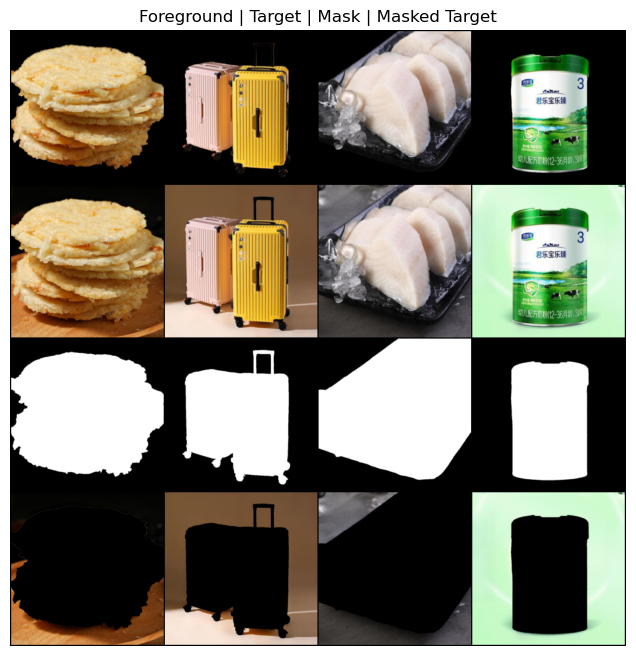

In [6]:
# 随机取一组样本
foreground, target, mask = next(iter(dataloader))

print(f"foreground: {foreground.shape}")
print(f"target:     {target.shape}")
print(f"mask:       {mask.shape}")
print(f"mask min/max: {mask.min().item()} - {mask.max().item()}")

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def visualize_debug(fg, target, mask):
    with torch.no_grad():
        masked_target = target * (1 - mask.expand(-1, 3, -1, -1))
        grid = make_grid(torch.cat([
            fg[:4], target[:4], mask[:4].repeat(1,3,1,1), masked_target[:4]
        ], dim=0), nrow=4)
        plt.figure(figsize=(12, 8))
        plt.imshow(grid.permute(1,2,0).cpu())
        plt.axis('off')
        plt.title('Foreground | Target | Mask | Masked Target')
        plt.show()

visualize_debug(foreground, target, mask)


In [8]:
# ----- 训练循环 -----
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for foreground, target, mask in tqdm(dataloader):
        foreground, target, mask = foreground.to(device), target.to(device), mask.to(device)

        # 应用 mask：将前景区域在 target 中遮掉（设为0或中性值）
        masked_target = target * (1 - mask.expand(-1, 3, -1, -1))

        optimizer.zero_grad()
        # recon, vq_loss = model(foreground, masked_target)
        # recon_loss = F.mse_loss(recon * (1 - mask.expand(-1, 3, -1, -1)), masked_target)
        recon, vq_loss = model(target, target)
        recon_loss = F.mse_loss(recon, target)
        loss = recon_loss + vq_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(dataloader):.4f}")

    # 每个 epoch 保存样例
    model.eval()
    with torch.no_grad():
        sample_recon, _ = model(foreground[:8], masked_target[:8])
        # utils.save_image(recon * (1 - mask.expand(-1, 3, -1, -1)), f"samples/recon_epoch{epoch+1}.png")
        utils.save_image(recon, f"samples/epoch{epoch+1}.png")
        utils.save_image(target[:8], f"samples/target_epoch{epoch+1}.png")


100%|██████████| 63/63 [00:51<00:00,  1.23it/s]


Epoch 1/100, Loss: 0.5043


100%|██████████| 63/63 [00:57<00:00,  1.10it/s]


Epoch 2/100, Loss: 0.3715


100%|██████████| 63/63 [00:53<00:00,  1.18it/s]


...

Epoch 31/100, Loss: 0.0156


100%|██████████| 63/63 [00:52<00:00,  1.21it/s]


Epoch 32/100, Loss: 0.0153


 57%|█████▋    | 36/63 [00:30<00:23,  1.17it/s]


KeyboardInterrupt: 

In [ ]:
# 最后一个 epoch 训练完成后：
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# 显示当前 batch 的输入前景图、原图（完整图）、重建图（背景）
def show_samples(fg, target, recon, mask):
    fg = fg[:4]
    target = target[:4]
    recon = recon[:4]
    mask = mask[:4]

    # 可视化去掉前景的重建图
    recon_bg = recon * (1 - mask)

    grid = make_grid(torch.cat([fg, target, recon_bg], dim=0), nrow=4)
    plt.figure(figsize=(12, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Foreground | Target | Reconstructed Background')
    plt.show()